In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys

from scipy import sparse, linalg
from scipy.io import loadmat,savemat
from math import factorial

from matplotlib.colors import ListedColormap

from numpy.random import randint
import sklearn as sk
from sklearn.mixture import GaussianMixture # jaxxx??? # Hyakkk

# # Seaborn colormap
# import seaborn as sns
# import colorcet as cc
# # Get lot's of colors
# sns_list = sns.color_palette(cc.glasbey,n_colors=20).as_hex()

# # sns_list.insert(0, '#ffffff')  # Insert white at zero position? probably only for plotting
# sns_cmap = ListedColormap(sns_list)

# cm = sns_cmap

# mpl_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
#             '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
#             '#bcbd22', '#17becf']


# Seaborn colormap
import seaborn as sns
import colorcet as cc
sns_list = sns.color_palette(cc.glasbey,n_colors=20).as_hex()
sns_list.pop(4)

# sns_list.insert(0, '#ffffff')  # Insert white at zero position
sns_cmap = ListedColormap(sns_list)
cm = sns_cmap

sns_list_balance_models = sns_list.copy()

sns_list_balance_models.insert(0, '#ffffff')  # Insert white at zero position
sns_list_balance_models.pop(1)
sns_cmap_balance_models = ListedColormap(sns_list_balance_models)

cm_balance_models = sns_cmap_balance_models

mpl_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
            '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
            '#bcbd22', '#17becf']

# Import Vinuesa derivative operator that was specifically given as 6th order accurate for the duct
from RicardoHelper import diff6

ModuleNotFoundError: No module named 'RicardoHelper'

In [26]:

def train_gmm_model(nc, features, seed=-1, sample_pct=0.95, mode='kmeans'):
    # use random seed if not specified
    if seed == -1:
        seed = randint(2**32)
    else:
        pass
    
    print(seed)
    model = GaussianMixture(n_components=nc, random_state=seed, n_init = 3, init_params=mode)

    # PERMUTATION
    mask = np.random.permutation(features.shape[0])[:int(sample_pct*features.shape[0])]
    model.fit(features[mask, :])

    return model


In [27]:
def Dx(f, x):
    ny,nx = f.shape
    dfdx = np.ndarray(f.shape)
    for i in range(ny):
        dfdx[i,:] = diff6(f[i,:], x)

    return dfdx

def Dy(f, y):
    ny,nx = f.shape
    dfdx = np.ndarray(f.shape)
    for i in range(nx):
        dfdx[:,i] = diff6(f[:,i], y)

    return dfdx

def square(terms_array):
    num_terms = terms_array.shape[1]
    num_outputs = int(np.math.factorial(num_terms) / (2 * np.math.factorial(num_terms-2))) + num_terms # n_terms choose 2 since we're squaring + themselves squared
    print(num_outputs)
    expanded = np.ndarray((terms_array.shape[0], num_outputs))

    # print(expanded.shape, num_terms, num_outputs)

    k = 0
    for i in range(num_terms):
        # print('i equals {}'.format(i))
        for j in range(i, num_terms):
            # print('j equals {}'.format(j))
            if i == j:
                expanded[:, k] = terms_array[:,i] * terms_array[:,j]
            else:
                expanded[:, k] = 2 * (terms_array[:,i] * terms_array[:,j])
            k += 1
            
    return expanded

In [2]:
# Load data

file_path = '../AR_1_180(HiFi)/duct180.mat'

data = loadmat(file_path,squeeze_me=True, struct_as_record=False)['duct180']

x = data.xx
y = data.yy

xx,yy = np.meshgrid(x,y)

nu = 1/2500 # 1/Re_b

U = data.time.U
V = data.time.V
W = data.time.W

uu = data.time.uu
uv = data.time.uv
uw = data.time.uw
vw = data.time.vw
vv = data.time.vv
ww = data.time.ww

In [4]:
def apply_symmetry(array):
    # assuming it's the full 194 x 193 array
    arr_top = array[97:, :]
    arr_topFlipped = np.flip(arr_top, axis = 0)
    arr_bottom = (arr_topFlipped + array[:97, :])/2

    arr_right = arr_bottom[:, 97:]
    arr_left = np.zeros_like(arr_bottom[:, 0:97])

    arr_rightFlipped = np.flip(arr_right, axis = 1)

    arr_left[:,:-1] = (arr_bottom[:, 0:96] + arr_rightFlipped)/2
    arr_left[:,-1] = arr_bottom[:,96]

    return arr_left

def apply_midline_symmetry(array):
    # assuming it's the full 194 x 193 array
    arr_top = array[97:, :]
    arr_topFlipped = np.flip(arr_top, axis = 0)
    arr_bottom = (arr_topFlipped + array[:97, :])/2

    arr_right = arr_bottom[:, 97:]
    arr_left = np.zeros_like(arr_bottom[:, 0:97])

    arr_rightFlipped = np.flip(arr_right, axis = 1)

    arr_left[:,:-1] = (arr_bottom[:, 0:96] - arr_rightFlipped)/2
    arr_left[:,-1] = arr_bottom[:,96]

    return arr_left

def apply_centerline_symmetry(array):
    # assuming it's the full 194 x 193 array
    arr_top = array[97:, :]
    arr_topFlipped = np.flip(arr_top, axis = 0)
    arr_bottom = (array[:97, :] - arr_topFlipped)/2

    arr_right = arr_bottom[:, 97:]
    arr_left = np.zeros_like(arr_bottom[:, 0:97])

    arr_rightFlipped = np.flip(arr_right, axis = 1)

    arr_left[:,:-1] = (arr_bottom[:, 0:96] + arr_rightFlipped)/2
    arr_left[:,-1] = arr_bottom[:,96]

    return arr_left

def apply_diagonal_symmetry(array):
    # assuming it's the full 194 x 193 array
    arr_top = array[97:, :]
    arr_topFlipped = np.flip(arr_top, axis = 0)
    arr_bottom = (array[:97, :] - arr_topFlipped)/2

    arr_right = arr_bottom[:, 97:]
    arr_left = np.zeros_like(arr_bottom[:, 0:97])

    arr_rightFlipped = np.flip(arr_right, axis = 1)

    arr_left[:,:-1] = (arr_bottom[:, 0:96] - arr_rightFlipped)/2
    arr_left[:,-1] = arr_bottom[:,96]

    return arr_left

In [5]:
# Take bottom left quad
xx_symm = xx[:97, :97]
yy_symm = yy[:97, :97]

# apply different symmetries based on what the full duct plots look like
U_symm = apply_midline_symmetry(U)
V_symm = apply_centerline_symmetry(V)
W_symm = apply_symmetry(W)

uu_symm = apply_symmetry(uu)
uv_symm = apply_diagonal_symmetry(uv)
uw_symm = apply_midline_symmetry(uw)
vv_symm = apply_symmetry(vv)
vw_symm = apply_centerline_symmetry(vw)
ww_symm = apply_symmetry(ww)

# Reframe in Norm/Tan

first, define some cartesian derivatives that we can use to calculate terms in the N/T coord frame

In [31]:
def calculate_features(xx_symm,yy_symm,U_symm, V_symm, W_symm,uu_symm,uv_symm,vv_symm):
    x_symm = xx_symm[0]
    y_symm = yy_symm[:, 0]
    # Get all the derivatives you've ever wanted
    Ux = Dx(U_symm, x_symm)
    Uy = Dy(U_symm, y_symm)

    Vx = Dx(V_symm, x_symm)
    Vy = Dy(V_symm, y_symm)

    Wx = Dx(W_symm, x_symm)
    Wy = Dy(W_symm, y_symm)

    vortX = Wy
    vortY = -Wx
    vortZ = Vx-Uy

    # Setup derivatives for convective, stretching, and dissipations terms
    vortZ_x = Dx(vortZ,x_symm)
    vortZ_y = Dy(vortZ,y_symm)

    vortZ_xx = Dx(vortZ_x,x_symm)
    vortZ_yy = Dy(vortZ_y,y_symm)

    # Setup derivatives for RSTs
    uv_xx = Dx(Dx(uv_symm,x_symm),x_symm)
    uv_yy = Dy(Dy(uv_symm,y_symm),y_symm)
    uu_xy = Dx(Dy(uu_symm,y_symm),x_symm)
    vv_xy = Dx(Dy(vv_symm,y_symm),x_symm)



    OmegaXW_x = vortX * Wx
    OmegaYW_y = vortY * Wy

    RS_shear =  uv_yy - uv_xx
    RS_normal = uu_xy - vv_xy

    return U_symm*vortZ_x, V_symm*vortZ_y, vortZ_xx, vortZ_yy, OmegaXW_x, OmegaYW_y, RS_shear, RS_normal, vortZ

    # UOmegaZ_x, VOmegaZ_y, OmegaZ_xx, OmegaZ_yy, OmegaXW_x, OmegaYW_y, RS_shear, RS_normal, OmegaZ

In [8]:
O6_TOmegaZ_t, O6_NOmegaZ_n, O6_OmegaZ_tt, O6_OmegaZ_nn, O6_OmegaTT_t, O6_OmegaNN_n, O6_RS_shear, O6_RS_normal,O6_Omega_z = calculate_features(xx_symm,yy_symm, U_symm, V_symm, W_symm, uu_symm, uv_symm, vv_symm)
O5_NOmegaZ_n, O5_TOmegaZ_t, O5_OmegaZ_nn, O5_OmegaZ_tt, O5_OmegaNN_n, O5_OmegaTT_t, O5_RS_shear, O5_RS_normal,O5_Omega_z = calculate_features(xx_symm,yy_symm, U_symm, V_symm, W_symm, uu_symm, uv_symm, vv_symm)


In [9]:
# init derivatives
convectiveDer_norm = np.zeros_like(xx_symm)
convectiveDer_tan = np.zeros_like(xx_symm)
stretching_norm = np.zeros_like(xx_symm)
stretching_tan = np.zeros_like(xx_symm)
dissipation_norm = np.zeros_like(xx_symm)
dissipation_tan = np.zeros_like(xx_symm)

# combine uv derivatives as well as u^2 and v^2
# shearRS_nn = np.zeros_like(xx_symm)
# shearRS_tt = np.zeros_like(xx_symm)
# normRS_nt = np.zeros_like(xx_symm)
# tangRS_nt = np.zeros_like(xx_symm)
RS_shear = np.zeros_like(xx_symm)
RS_normal = np.zeros_like(xx_symm)
Omega_z = np.zeros_like(xx_symm)

In [10]:
for i,x_coord in enumerate(xx_symm[0]):
    for j,y_coord in enumerate(yy_symm[:, 0]):
        if x_coord > y_coord:
            convectiveDer_tan[j,i] = O6_TOmegaZ_t[j,i]
            convectiveDer_norm[j,i] = O6_NOmegaZ_n[j,i]
            dissipation_tan[j,i] = O6_OmegaZ_tt[j,i]
            dissipation_norm[j,i] = O6_OmegaZ_nn[j,i]
            stretching_tan[j,i] = O6_OmegaTT_t[j,i]
            stretching_norm[j,i] = O6_OmegaNN_n[j,i]
            RS_shear[j,i]  = O6_RS_shear[j,i]
            RS_normal[j,i] = O6_RS_normal[j,i]
            Omega_z[j,i]   = O6_Omega_z[j,i]
        else:
            convectiveDer_tan[j,i] = -O5_TOmegaZ_t[j,i]
            convectiveDer_norm[j,i] = -O5_NOmegaZ_n[j,i]
            dissipation_tan[j,i] = -O5_OmegaZ_tt[j,i]
            dissipation_norm[j,i] = -O5_OmegaZ_nn[j,i]
            stretching_tan[j,i] = O5_OmegaTT_t[j,i]
            stretching_norm[j,i] = O5_OmegaNN_n[j,i]
            RS_shear[j,i]  = -O5_RS_shear[j,i]
            RS_normal[j,i] = -O5_RS_normal[j,i]
            Omega_z[j,i]   = -O5_Omega_z[j,i]

In [6]:
NTlabels_full = [r'$T \frac{\partial \Omega_x}{\partial t}$', r'$N \frac{\partial \Omega_x}{\partial n}$',
            r'$\frac{\partial^2 \Omega_x}{\partial t^2}$', r'$\frac{\partial^2 \Omega_x}{\partial n^2}$', 
            #r'$\Omega_x\frac{\partial U}{\partial x}$', r'$\Omega_y\frac{\partial V}{\partial y}$',
            r'$(RS_{\hat{t}})$', r'$(RS_{\hat{n}})$']

In [7]:
xx_left = xx_symm
yy_left = yy_symm

In [ ]:
feature_scaling = 1e1 #  magnitude of sthe eed of GMMs as implemented by scipy

features = feature_scaling * np.array([convectiveDer_tan.flatten(),
                convectiveDer_norm.flatten(),
                nu*dissipation_tan.flatten(),
                nu*dissipation_norm.flatten(),
                RS_shear.flatten(),
                RS_normal.flatten()
                ]).T

nc = 10
nfeatures = 6
# for nc in nc_arr:

# nc_save_dir = save_dir_trial + f'nc{nc}/'
# save_dir_trial = nc_save_dir + f'trial_{trial}/' 
# os.mkdir(save_dir_trial)

model = train_gmm_model(nc,features)
cluster_idx = model.predict(features)+1

# np.save(save_dir_trial + 'cluster_idx',cluster_idx)

plt.figure(figsize = (5,4))
plt.pcolormesh(xx_left,yy_left,cluster_idx.reshape(xx_left.shape), cmap = cm, vmin=-0.5, vmax=cm.N-0.5)
plt.colorbar(boundaries=np.arange(0.5, nc+1.5), ticks=np.arange(0, nc+1))
plt.show()
plt.close()

if nc > 16:
    C_list = []
    plt.figure(figsize=(19, 16))
    for j in range(nc):
        plt.subplot(5, 4, j+1)
        # get CVs
        jth_cluster = (cluster_idx == j+1)
        cluster_mask = np.array([k for k, x in enumerate(jth_cluster) if x])
        C = np.cov(features[cluster_mask].T)
        C_list.append(C)
        plt.pcolor(C, vmin=-max(abs(C.flatten())), vmax=max(abs(C.flatten())), cmap='RdBu')
        plt.gca().set_xticks(np.arange(0.5, nfeatures+0.5))
        plt.gca().set_xticklabels(NTlabels_full, fontsize=8)
        plt.gca().set_yticks(np.arange(0.5, nfeatures+0.5))
        plt.gca().set_yticklabels(NTlabels_full, fontsize=8)
        plt.gca().set_title('Cluster {0}'.format(j+1), fontsize=14)

    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.3)
    plt.suptitle("CV of CFD Data in Ensembled Clusters")
    plt.show()
    plt.close()
elif nc > 12:

    C_list = []
    plt.figure(figsize=(16, 16))
    for j in range(nc):
        plt.subplot(4, 4, j+1)
        # get CVs
        jth_cluster = (cluster_idx == j+1)
        cluster_mask = np.array([k for k, x in enumerate(jth_cluster) if x])
        C = np.cov(features[cluster_mask].T)
        C_list.append(C)
        plt.pcolor(C, vmin=-max(abs(C.flatten())), vmax=max(abs(C.flatten())), cmap='RdBu')
        plt.gca().set_xticks(np.arange(0.5, nfeatures+0.5))
        plt.gca().set_xticklabels(NTlabels_full, fontsize=8)
        plt.gca().set_yticks(np.arange(0.5, nfeatures+0.5))
        plt.gca().set_yticklabels(NTlabels_full, fontsize=8)
        plt.gca().set_title('Cluster {0}'.format(j+1), fontsize=14)

    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.3)
    plt.suptitle("CV of CFD Data in Ensembled Clusters")
    plt.show()
    plt.close() 
elif nc > 9:

    C_list = []
    plt.figure(figsize=(13, 16))
    for j in range(nc):
        plt.subplot(4, 3, j+1)
        # get CVs
        jth_cluster = (cluster_idx == j+1)
        cluster_mask = np.array([k for k, x in enumerate(jth_cluster) if x])
        C = np.cov(features[cluster_mask].T)
        C_list.append(C)
        plt.pcolor(C, vmin=-max(abs(C.flatten())), vmax=max(abs(C.flatten())), cmap='RdBu')
        plt.gca().set_xticks(np.arange(0.5, nfeatures+0.5))
        plt.gca().set_xticklabels(NTlabels_full, fontsize=8)
        plt.gca().set_yticks(np.arange(0.5, nfeatures+0.5))
        plt.gca().set_yticklabels(NTlabels_full, fontsize=8)
        plt.gca().set_title('Cluster {0}'.format(j+1), fontsize=14)

    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.3)
    plt.suptitle("CV of CFD Data in Ensembled Clusters")
    plt.show()
    plt.close()
elif nc > 6:
    C_list = []
    plt.figure(figsize=(13, 13))
    for j in range(nc):
        plt.subplot(3, 3, j+1)
        # get CVs
        jth_cluster = (cluster_idx == j+1)
        cluster_mask = np.array([k for k, x in enumerate(jth_cluster) if x])
        C = np.cov(features[cluster_mask].T)
        C_list.append(C)
        plt.pcolor(C, vmin=-max(abs(C.flatten())), vmax=max(abs(C.flatten())), cmap='RdBu')
        plt.gca().set_xticks(np.arange(0.5, nfeatures+0.5))
        plt.gca().set_xticklabels(NTlabels_full, fontsize=8)
        plt.gca().set_yticks(np.arange(0.5, nfeatures+0.5))
        plt.gca().set_yticklabels(NTlabels_full, fontsize=8)
        plt.gca().set_title('Cluster {0}'.format(j+1), fontsize=14)

    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.3)
    plt.suptitle("CV of CFD Data in Ensembled Clusters")
    plt.show()
    plt.close()
else:
    C_list = []
    plt.figure(figsize=(13, 10))
    for j in range(nc):
        plt.subplot(2, 3, j+1)
        # get CVs
        jth_cluster = (cluster_idx == j+1)
        cluster_mask = np.array([k for k, x in enumerate(jth_cluster) if x])
        C = np.cov(features[cluster_mask].T)
        C_list.append(C)
        plt.pcolor(C, vmin=-max(abs(C.flatten())), vmax=max(abs(C.flatten())), cmap='RdBu')
        plt.gca().set_xticks(np.arange(0.5, nfeatures+0.5))
        plt.gca().set_xticklabels(NTlabels_full, fontsize=14)
        plt.gca().set_yticks(np.arange(0.5, nfeatures+0.5))
        plt.gca().set_yticklabels(NTlabels_full, fontsize=14)
        plt.gca().set_title('Cluster {0}'.format(j+1), fontsize=14)

    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.3)
    plt.suptitle("CV of CFD Data in Ensembled Clusters")
    plt.show()
    plt.close()


In [13]:
# load features constructed from higher order FD and cluster_idx to reproduce paper results
cluster_idx = np.load("cluster_idx.npy")
features = np.load("features.npy")

nc = 10
nfeatures = 6

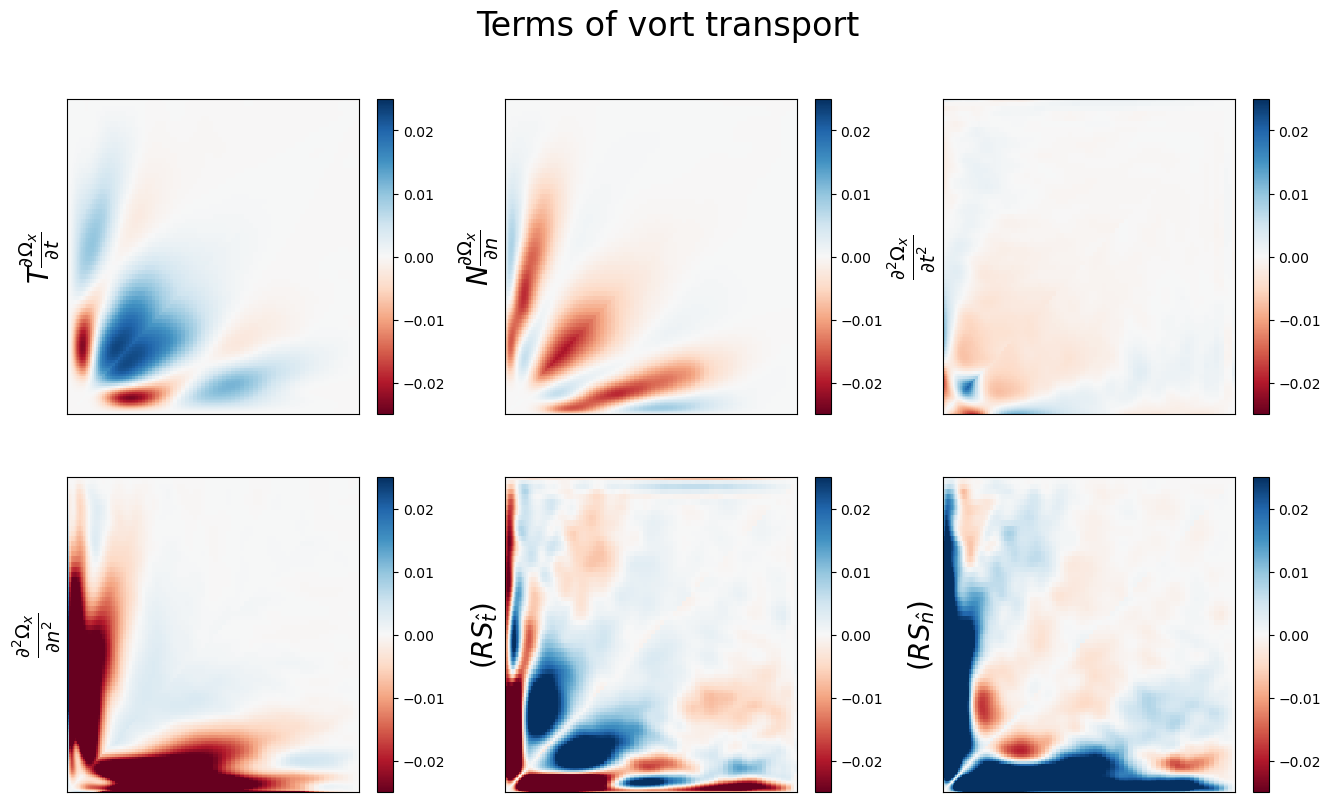

In [33]:


fig = plt.figure(figsize=(16, 9))

fig.suptitle('Terms of vort transport', fontsize=24)

clim = 0.025

# clim = 5e-4
fontsize=20
fig.add_subplot(231)
plt.pcolormesh(xx_left,yy_left,convectiveDer_norm,cmap='RdBu',vmin = -clim, vmax = clim)
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.ylabel(NTlabels_full[0], fontsize=fontsize)

fig.add_subplot(232)
plt.pcolormesh(xx_left,yy_left,convectiveDer_tan,cmap='RdBu',vmin = -clim, vmax = clim)
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.ylabel(NTlabels_full[1], fontsize=fontsize)

fig.add_subplot(233)
plt.pcolormesh(xx_left,yy_left,nu*dissipation_tan,cmap='RdBu',vmin = -clim, vmax = clim)
# plt.pcolormesh(xx_left,yy_left,np.log10(np.abs(dissipation_norm)),cmap='RdBu',vmin = -clim, vmax = clim)
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.ylabel(NTlabels_full[2], fontsize=fontsize)

fig.add_subplot(234)
plt.pcolormesh(xx_left,yy_left,nu*dissipation_norm,cmap='RdBu',vmin = -clim, vmax = clim)
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.ylabel(NTlabels_full[3], fontsize=fontsize)

fig.add_subplot(235)
plt.pcolormesh(xx_left,yy_left,RS_shear,cmap='RdBu',vmin = -clim, vmax = clim)
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.ylabel(NTlabels_full[4], fontsize=fontsize)

fig.add_subplot(236)
plt.pcolormesh(xx_left,yy_left,RS_normal,cmap='RdBu',vmin = -clim, vmax = clim)
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.ylabel(NTlabels_full[5], fontsize=fontsize)

plt.show()

In [9]:
from sklearn.decomposition import SparsePCA
from scipy.io import loadmat
import h5py
from scipy import sparse, linalg
from scipy.optimize import curve_fit, root
from scipy.integrate import odeint
from scipy.interpolate import interp1d

import matplotlib as mpl

In [10]:
def test_alpha_sPCA_GMM_model(alphas, features,cluster_idx,cluster_idx_to_test,nfeatures=6):
    err = np.zeros([len(alphas)])  # Error defined as norm of inactive terms
    sparsity = np.zeros([len(alphas)])
    for k in range(len(alphas)):
        i = cluster_idx_to_test
        # Identify points in the field corresponding to each cluster
        feature_idx = np.nonzero(cluster_idx==i)[0]
        cluster_features = features[feature_idx, :]
        spca = SparsePCA(n_components=1, alpha=alphas[k])
        spca.fit(cluster_features)
        active_terms = np.nonzero(spca.components_[0])[0]
        inactive_terms = [feat for feat in range(nfeatures) if feat not in active_terms ]

        err[k] += np.linalg.norm(cluster_features[:, inactive_terms])

    return err

In [14]:
cluster_err = []
alphas = 10e3*np.array([0.000001,0.00001,0.0001,0.0005,0.001,0.0025,0.005,0.01,0.0125,0.015,0.0175,0.02,0.0225,0.025,0.0325,0.0375,0.048,0.05,0.0625,0.075,0.0875,0.1,0.11,0.12,0.13,0.14,0.15,0.175,0.2,0.225,0.25,0.3,0.35,0.4,0.45,0.5,0.625,0.75,0.875,1])

for i in range(nc):
    cluster_err.append(test_alpha_sPCA_GMM_model(alphas, features, cluster_idx-1, i))

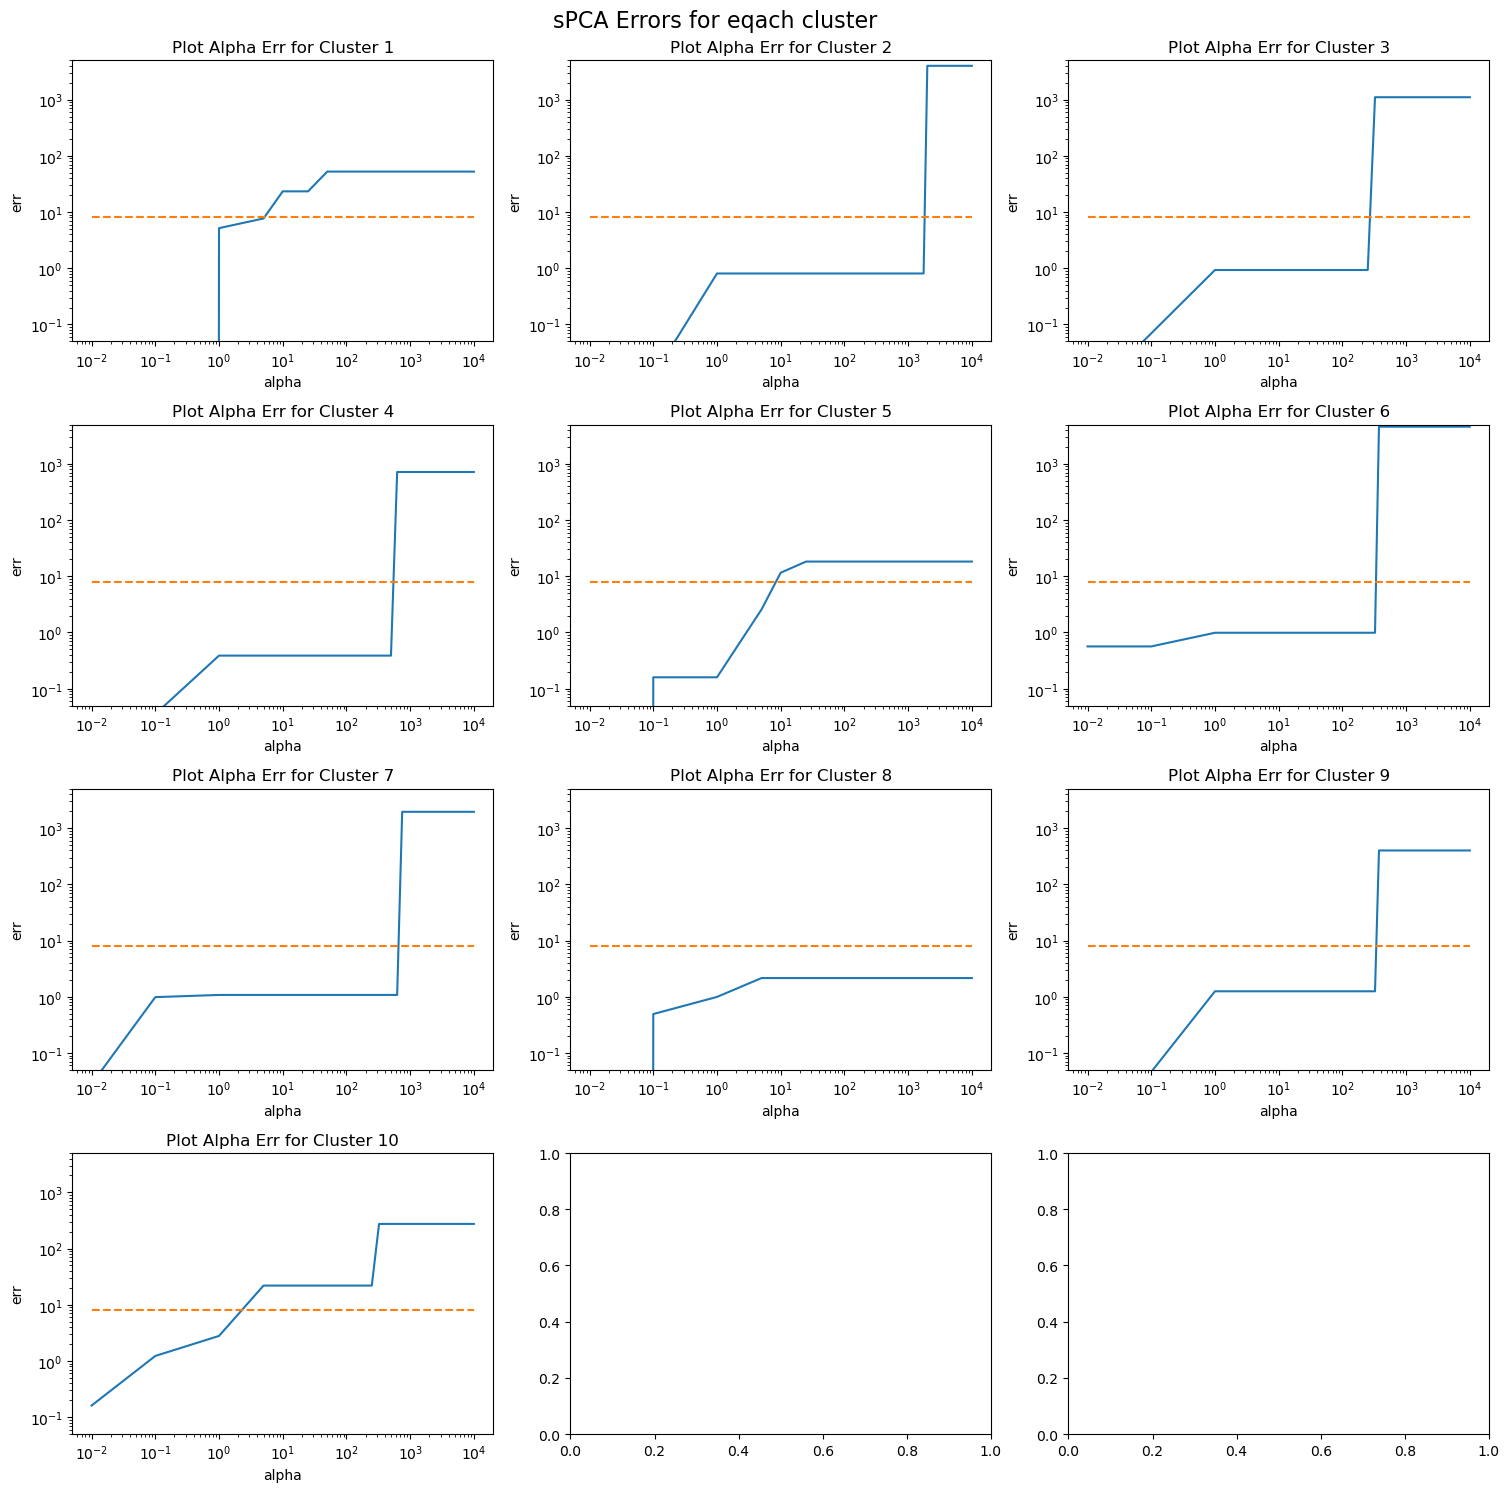

In [15]:
# Create figure and axes with 3x3 subplots, sharing the x-axis
fig, axes = plt.subplots(4, 3, figsize=(16, 16))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plotting
for i in range(nc):
    axes[i].loglog(alphas, cluster_err[i])
    axes[i].set_title(f'Plot Alpha Err for Cluster {i + 1}')
    axes[i].loglog(alphas, 8.0 * np.ones_like(np.array(alphas)), linestyle='--')
    # if i == 2:
    #     axes[i].set_xlim(0.0625,0.0875)
    axes[i].set_xlabel('alpha')
    axes[i].set_ylabel('err')
    axes[i].set_ylim(5e-2,5000)

# # Add shared x-label and y-label
# fig.text(0.5, 0.04, 'X Axis', ha='center')
# fig.text(0.04, 0.5, 'Y Axis', va='center', rotation='vertical')

# Adjust layout
plt.tight_layout(rect=[0.05, 0.05, 1, 0.97])
plt.suptitle("sPCA Errors for eqach cluster", fontsize=16)
plt.show()

In [16]:
def train_sPCA_model_multi_alpha(opt_alpha_list, features, nfeatures, nc, cluster_idx):
    spca_model = np.zeros([nc, nfeatures])
    for i in range(nc):
        alpha_opt = opt_alpha_list[i]
        feature_idx = np.nonzero(cluster_idx==i)[0]
        cluster_features = features[feature_idx, :]
        spca = SparsePCA(n_components=1, alpha=alpha_opt)
        spca.fit(cluster_features)
        # print('GMM Cluster {0}:'.format(i))
        active_terms = np.nonzero(spca.components_[0])[0]
        if len(active_terms)>0:
            # print([labels[k] for k in active_terms])
            spca_model[i, active_terms] = 1  # Set to 1 for active terms in model
        else: print('None')

    return spca_model

In [17]:
# err_threshold = 28 maximum I can truncate before I loose viscous effect in the part over the the 
err_threshold = 8.0

alpha_opt = []
for i in range(nc):
    for j,err in enumerate(cluster_err[i]):
        if err > err_threshold:
            alpha_opt.append(alphas[j-1]) # append the last alpha value that was not above the error threshold
            break
        elif j == cluster_err[i].size - 1:
            alpha_opt.append(alphas[j-1]) # append the last alpha value if there are no alphas that surpass the error level
        else:
            continue

print(alpha_opt)
optimal_alphas = alpha_opt

[5.0, 1750.0, 250.0, 500.0, 5.0, 325.0, 625.0, 8750.0, 325.0, 1.0]


In [18]:
spca_model = train_sPCA_model_multi_alpha(optimal_alphas, features, nfeatures, nc, cluster_idx.flatten()-1)

None


In [19]:
balance_models, model_index = np.unique(spca_model, axis=0, return_inverse=True)

# print(balance_models)
nmodels = balance_models.shape[0]

balance_idx = np.array([model_index[i] for i in cluster_idx.flatten() - 1])

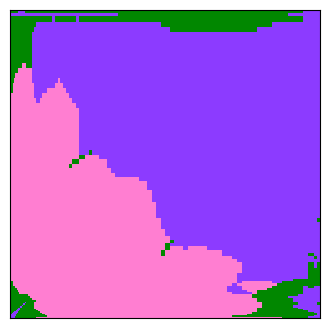

<Figure size 640x480 with 0 Axes>

In [20]:
plt.figure(figsize = (4.0,4.0))
plt.pcolormesh(xx_left,yy_left, (balance_idx+1).reshape(xx_left.shape), cmap = cm_balance_models, vmin=-0.5, vmax=cm.N-0.5)
# plt.colorbar(boundaries=np.arange(0.5, int(nmodels)+1.5), ticks=np.arange(1, int(nmodels)+2))
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.savefig(f'VortTran_sPCA_ClusterDomain,nc{nc}', transparent=True,dpi=480)
plt.show()
plt.clf()

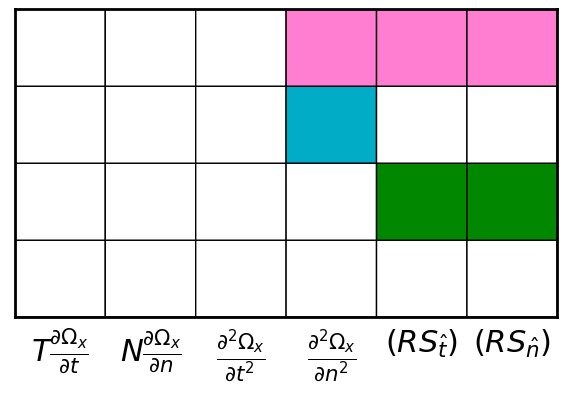

<Figure size 640x480 with 0 Axes>

In [21]:
# Plot a grid with active terms in each cluster
gridmap = balance_models.copy()
gridmask = gridmap==0
gridmap = (gridmap.T*np.arange(nmodels)).T+1  # Scale map so that active terms can be color-coded
gridmap[gridmask] = 0

# NOTE We're skipping the deleting of unidentified terms because I need to count terms correctly identified as 0 in my quantitative metric
# plot spca_model matrix
# Delete zero terms
# grid_mask = np.nonzero( np.all(gridmap==0, axis=0) )[0]
# gridmap = np.delete(gridmap, grid_mask, axis=1)
# grid_labels = np.delete(labels, grid_mask)

grid_labels = NTlabels_full

plt.figure(figsize=(7, 4))
plt.pcolor(gridmap, vmin=-0.5, vmax=cm.N-0.5, cmap=cm_balance_models, edgecolors='k', linewidth=1)
plt.gca().set_xticks(np.arange(0.5, gridmap.shape[1]+0.5))
plt.gca().set_xticklabels(grid_labels, fontsize=22)
plt.gca().set_yticklabels([])

for axis in ['top','bottom','left','right']:
    plt.gca().spines[axis].set_linewidth(2)

plt.gca().tick_params(axis='both', width=0)
plt.savefig(f'DuctRANS_sPCA_Matrix_Model', bbox_inches='tight',transparent=True,dpi=480)
plt.show()
plt.clf()

# save cluster_idx np array and spca_model np
# np.save(save_dir + f'trial{i}/spca_model.npy', balance_models)
# np.save(save_dir + f'trial{i}/cluster_idx.npy', balancemap)

In [78]:
# np.save("cluster_idx.npy",cluster_idx)
# np.save("features.npy",features)

In [27]:
# cluster_idx = np.load("cluster_idx.npy")
# features = np.load("features.npy")